In [32]:
import pandas as pd
import glob

files = glob.glob("WaterQualityWaterQualityStation_*.csv")

df_list = [pd.read_csv(f) for f in files]

df = pd.concat(df_list, ignore_index=True)

C:\Users\zseal\AppData\Local\Temp\ipykernel_40524\3246148124.py:6: DtypeWarning: Columns (23,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in files]
C:\Users\zseal\AppData\Local\Temp\ipykernel_40524\3246148124.py:6: DtypeWarning: Columns (23,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in files]


In [33]:
keep_cols = [
    "MonitoringStation",
    "SampleDate",
    "SampleTime",
    "Latitude",
    "Longitude",
    "MeasureValue"
]

df = df[keep_cols]

In [34]:
df.to_csv("Chesapeake_Bay_Salinity_Combined.csv", index=False)

In [38]:
print(df.describe())
print(df.isna().sum())
print(df["Station"].value_counts().head())

                          SampleDate       Latitude      Longitude  \
count                         777981  777981.000000  777981.000000   
mean   2003-11-13 02:53:56.219907584      38.040923     -76.218666   
min              1985-01-09 00:00:00      36.947370     -76.502170   
25%              1993-03-30 00:00:00      37.411530     -76.359670   
50%              2003-05-06 00:00:00      37.910110     -76.227870   
75%              2014-02-19 00:00:00      38.643540     -76.079660   
max              2025-10-23 00:00:00      39.547940     -75.791320   
std                              NaN       0.700054       0.163494   

        MeasureValue           Year  
count  777191.000000  777981.000000  
mean    13645.058463    2003.365947  
min         0.000000    1985.000000  
25%        17.790000    1993.000000  
50%        36.000000    2003.000000  
75%     28000.000000    2014.000000  
max     51700.000000    2025.000000  
std     15218.388224      11.847162  
MonitoringStation      1
Sa

KeyError: 'Station'

In [43]:
import numpy as np

df["MeasureValue"] = pd.to_numeric(df["MeasureValue"])
df["MeasureValue"] = df["MeasureValue"].replace(0, np.nan)

df = df.dropna(subset=["MeasureValue"])

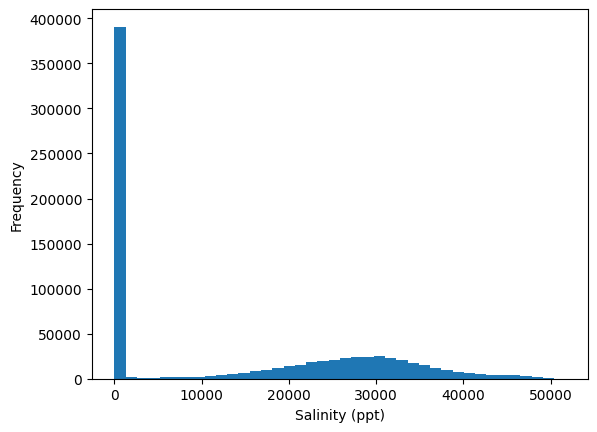

MeasureValue
17.25       1230
27000.00    1215
26000.00    1215
15.75       1183
16.43       1180
16.90       1180
17.79       1168
16.63       1165
16.97       1161
28200.00    1160
28000.00    1150
27300.00    1146
17.31       1144
17.11       1139
26400.00    1137
25000.00    1137
15.20       1136
17.93       1136
18.21       1131
29000.00    1131
Name: count, dtype: int64


In [46]:
plt.hist(df["MeasureValue"], bins=40)
plt.xlabel("Salinity (ppt)")
plt.ylabel("Frequency")
plt.show()
print(df["MeasureValue"].value_counts().head(20))